# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
#librerias
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [3]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
url="https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip"
data = pd.read_csv(url)
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,0,0,0,1,0,0,0
11,13995,2014,39972,0,0,0,0,1,0,0
167,17941,2016,18989,0,0,0,0,0,1,0
225,12493,2014,51330,0,0,0,1,0,0,0
270,7994,2007,116065,0,1,0,0,0,0,0


In [4]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [5]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Random forest con librería

En la celda 1, usando la librería sklearn entrenen un modelo de Randon Forest para clasificación  y comenten sobre el desempeño del modelo.

In [6]:
# Celda 1
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 7. Predicciones y evaluación
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("MSE del modelo:", mse)
print("R² del modelo:", r2)
print("MAE del modelo:", mae)
print("MAPE del modelo:", mape)


MSE del modelo: 3116678.915374798
R² del modelo: 0.7962441677396794
MAE del modelo: 1314.4207078056425
MAPE del modelo: 9.545143938665934


### Punto 2 - Calibración de parámetros Random forest

En la celda 2, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para clasificación, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

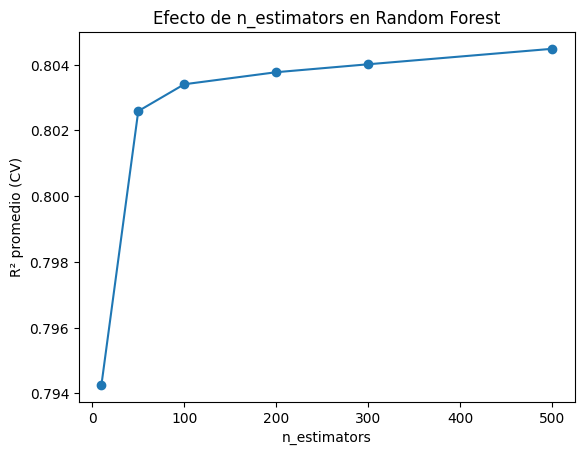

In [7]:
# Rango de valores para n_estimators
param_dist = {
    'n_estimators': [10, 50, 100, 200, 300, 500]
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=len(param_dist['n_estimators']),  # probar todos
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

random_search.fit(X_train, y_train)

results = pd.DataFrame(random_search.cv_results_)

plt.plot(results['param_n_estimators'], results['mean_test_score'], marker='o')
plt.xlabel('n_estimators')
plt.ylabel('R² promedio (CV)')
plt.title('Efecto de n_estimators en Random Forest')
plt.show()


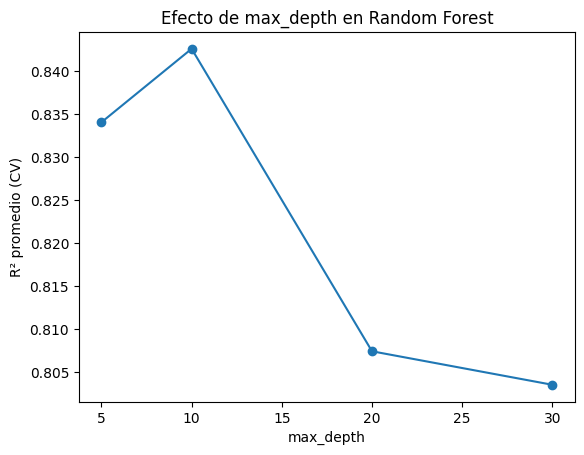

In [23]:
# Rango de valores para max_depth
param_dist = {
    'max_depth': [5, 10, 20, 30, None]
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=len(param_dist['max_depth']),  # probar todos
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

random_search.fit(X_train, y_train)

results = pd.DataFrame(random_search.cv_results_)

plt.plot(results['param_max_depth'], results['mean_test_score'], marker='o')
plt.xlabel('max_depth')
plt.ylabel('R² promedio (CV)')
plt.title('Efecto de max_depth en Random Forest')
plt.show()


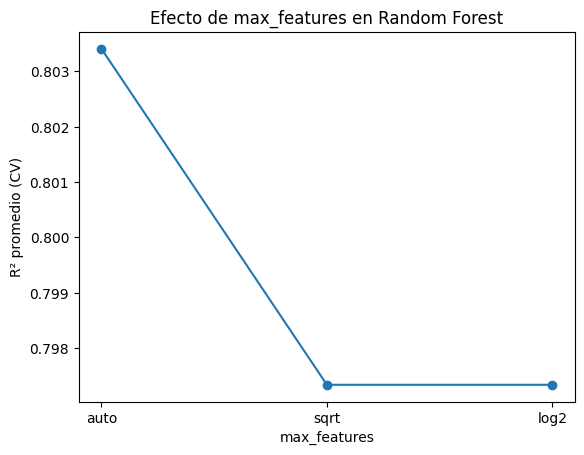

In [ ]:
# Rango de valores para max_features
param_dist = {
    'max_features': ['auto', 'sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=len(param_dist['max_features']),
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

random_search.fit(X_train, y_train)

results = pd.DataFrame(random_search.cv_results_)

plt.plot(results['param_max_features'], results['mean_test_score'], marker='o')
plt.xlabel('max_features')
plt.ylabel('R² promedio (CV)')
plt.title('Efecto de max_features en Random Forest')
plt.show()

In [8]:

# Definir el modelo base
rf = RandomForestRegressor(random_state=42)

# Definir la grilla de parámetros
param_dist = {
    'n_estimators': [10, 50, 100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'max_features': ['auto', 'sqrt'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# RandomizedSearch
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,  # probar 50 combinaciones aleatorias
    cv=5,  # validación cruzada con 5 folds
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Entrenar
random_search.fit(X_train, y_train)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=sqrt, max_depth=None 
[CV] n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=sqrt, max_depth=None 
[CV] n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=sqrt, max_depth=None 
[CV] n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=sqrt, max_depth=None 


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


[CV]  n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=sqrt, max_depth=None, total=   2.9s
[CV] n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=sqrt, max_depth=None 
[CV]  n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=sqrt, max_depth=None, total=   3.0s
[CV] n_estimators=200, min_samples_split=2, min_samples_leaf=2, max_features=sqrt, max_depth=10 
[CV]  n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=sqrt, max_depth=None, total=   3.0s
[CV]  n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=sqrt, max_depth=None, total=   3.0s
[CV] n_estimators=200, min_samples_split=2, min_samples_leaf=2, max_features=sqrt, max_depth=10 
[CV] n_estimators=200, min_samples_split=2, min_samples_leaf=2, max_features=sqrt, max_depth=10 
[CV]  n_estimators=200, min_samples_split=2, min_samples_leaf=2, max_features=sqrt, max_depth=10, total=   1.7s
[CV] n_estimators=200, min_samples_split=2

[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:   16.1s


[CV]  n_estimators=500, min_samples_split=2, min_samples_leaf=1, max_features=sqrt, max_depth=30, total=   8.1s
[CV] n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=auto, max_depth=20 
[CV]  n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=auto, max_depth=20, total=   4.6s
[CV] n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=auto, max_depth=20 
[CV]  n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=auto, max_depth=20, total=   4.5s
[CV] n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=auto, max_depth=20 
[CV]  n_estimators=300, min_samples_split=5, min_samples_leaf=4, max_features=auto, max_depth=20, total=   4.6s
[CV] n_estimators=200, min_samples_split=10, min_samples_leaf=2, max_features=sqrt, max_depth=20 
[CV]  n_estimators=200, min_samples_split=10, min_samples_leaf=2, max_features=sqrt, max_depth=20, total=   2.0s
[CV] n_estimators=200, min_samples_split=10, min_s

[Parallel(n_jobs=-1)]: Done 154 tasks      | elapsed:  1.7min


[CV]  n_estimators=300, min_samples_split=10, min_samples_leaf=2, max_features=auto, max_depth=30, total=   4.8s
[CV] n_estimators=200, min_samples_split=2, min_samples_leaf=2, max_features=sqrt, max_depth=None 
[CV]  n_estimators=300, min_samples_split=10, min_samples_leaf=2, max_features=auto, max_depth=30, total=   4.7s
[CV] n_estimators=300, min_samples_split=10, min_samples_leaf=2, max_features=sqrt, max_depth=30 
[CV]  n_estimators=200, min_samples_split=2, min_samples_leaf=2, max_features=sqrt, max_depth=None, total=   2.4s
[CV] n_estimators=300, min_samples_split=10, min_samples_leaf=2, max_features=sqrt, max_depth=30 
[CV]  n_estimators=200, min_samples_split=2, min_samples_leaf=2, max_features=sqrt, max_depth=None, total=   2.4s
[CV] n_estimators=300, min_samples_split=10, min_samples_leaf=2, max_features=sqrt, max_depth=30 
[CV]  n_estimators=200, min_samples_split=2, min_samples_leaf=2, max_features=sqrt, max_depth=None, total=   2.4s
[CV] n_estimators=300, min_samples_spli

[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:  2.6min finished


RandomizedSearchCV(cv=5, error_score=nan,
                   estimator=RandomForestRegressor(bootstrap=True,
                                                   ccp_alpha=0.0,
                                                   criterion='mse',
                                                   max_depth=None,
                                                   max_features='auto',
                                                   max_leaf_nodes=None,
                                                   max_samples=None,
                                                   min_impurity_decrease=0.0,
                                                   min_impurity_split=None,
                                                   min_samples_leaf=1,
                                                   min_samples_split=2,
                                                   min_weight_fraction_leaf=0.0,
                                                   n_estimators=100,
                              

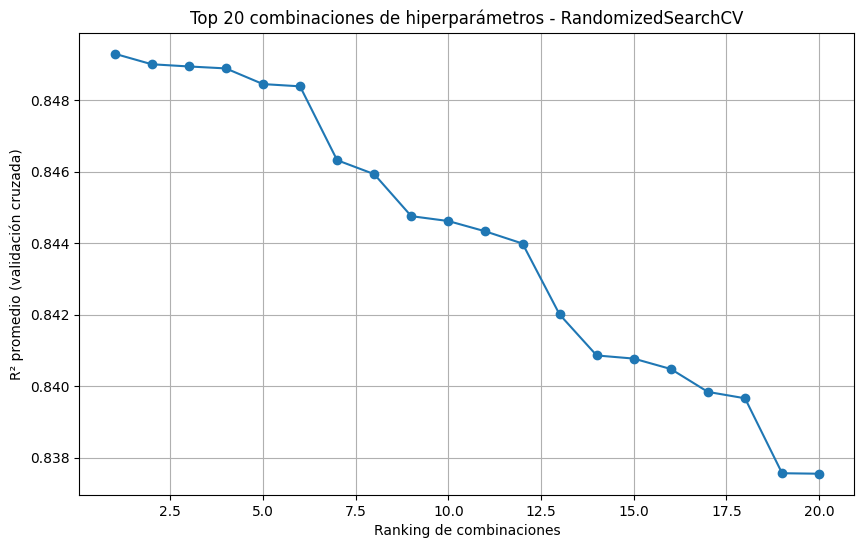

Mejores hiperparámetros encontrados:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}

Mejor R² en validación cruzada: 0.8493051472335482


In [9]:
results = pd.DataFrame(random_search.cv_results_)

# Ordenar por mejor score
results = results.sort_values(by="mean_test_score", ascending=False)

# Graficar los 20 mejores resultados
plt.figure(figsize=(10,6))
plt.plot(range(1, 21), results["mean_test_score"].head(20), marker='o')
plt.title("Top 20 combinaciones de hiperparámetros - RandomizedSearchCV")
plt.xlabel("Ranking de combinaciones")
plt.ylabel("R² promedio (validación cruzada)")
plt.grid(True)
plt.show()

# Mostrar mejores hiperparámetros
print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)
print("\nMejor R² en validación cruzada:", random_search.best_score_)

In [14]:
#Encontrar los mejores hiperparametros: 
print("Mejores parámetros:", random_search.best_params_)

#Entrenar el modelo con los mejores hiperparámetros encontrados:
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("R² en test:", r2_score(y_test, y_pred_best))
print("MSE en test:", mean_squared_error(y_test, y_pred_best))
print("MAE en test:", mean_absolute_error(y_test, y_pred_best))
print("MAPE en test:", np.mean(np.abs((y_test - y_pred_best)/y_test))*100)

Mejores parámetros: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
R² en test: 0.8423184187793854
MSE en test: 2411920.4544063094
MAE en test: 1140.8412941985214
MAPE en test: 8.327425550582753


In [28]:
#Importancia de los predictores
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

# Mostrar tabla
print(feature_importance)

       feature  importance
0         Year    0.448241
1      Mileage    0.424250
3   M_Camry4dr    0.066602
7    M_CamrySE    0.022088
8   M_CamryXLE    0.019215
6    M_CamryLE    0.007427
2      M_Camry    0.006767
4  M_CamryBase    0.002741
5     M_CamryL    0.002669


### Punto 3 - análisis de resultados, gracias y conclusiones
En la celda 3

In [ ]:
#celda 3
# Con la primera prueba del modelo se utilizo un n_estimators = 100 con el cuales se obtivieron buenos valores de sus metricas, siendo la mas destacable la de R2 de 0.79 un buen valor pero lejos de el mejor posible
# Se realizo la busqueda de los hiperparametros de manera individual usando un grafico para poder identificar le mejor y luego en conjunto, teniendo como mejores hacerlo en conjunto